In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

print("xarray :", xr.__version__)
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)

print("\nLibraries loaded successfully.")

xarray : 2025.12.0
numpy  : 2.1.3
pandas : 2.2.3

Libraries loaded successfully.


In [2]:
from pathlib import Path

files = [
    "SST.nc",
    "SSS.nc",
    "SSH_SLA.nc",
    "Surface_Currents.nc",
    "GLORYS_thetao.nc"
]

print("========== FILE CHECK ==========")

for filename in files:
    path = Path(filename)

    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"✅ {filename:25s} {size_mb:.2f} MB")
    else:
        print(f"❌ {filename:25s} NOT FOUND")

========== FILE CHECK ==========
✅ SST.nc                    83.33 MB
✅ SSS.nc                    83.33 MB
✅ SSH_SLA.nc                83.33 MB
✅ Surface_Currents.nc       166.65 MB
✅ GLORYS_thetao.nc          194.35 MB


In [3]:
import xarray as xr

# Open all datasets
sst = xr.open_dataset("SST.nc")
sss = xr.open_dataset("SSS.nc")
ssh = xr.open_dataset("SSH_SLA.nc")
currents = xr.open_dataset("Surface_Currents.nc")
glorys = xr.open_dataset("GLORYS_thetao.nc")

datasets = {
    "SST": sst,
    "SSS": sss,
    "SSH_SLA": ssh,
    "Surface_Currents": currents,
    "GLORYS_TARGET": glorys
}

for name, ds in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(ds)


SST
<xarray.Dataset> Size: 87MB
Dimensions:                  (time: 455, latitude: 100, longitude: 240)
Coordinates:
  * time                     (time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude                 (latitude) float64 800B 5.125 5.375 ... 29.62 29.88
  * longitude                (longitude) float64 2kB 45.12 45.38 ... 104.6 104.9
Data variables:
    sea_surface_temperature  (time, latitude, longitude) float64 87MB ...

SSS
<xarray.Dataset> Size: 87MB
Dimensions:               (time: 455, latitude: 100, longitude: 240)
Coordinates:
  * time                  (time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude              (latitude) float64 800B 5.125 5.375 ... 29.62 29.88
  * longitude             (longitude) float64 2kB 45.12 45.38 ... 104.6 104.9
    depth                 float32 4B ...
Data variables:
    sea_surface_salinity  (time, latitude, longitude) float64 87MB ...

SSH_SLA
<xarray.Dataset> Size: 87MB
Dimensions:            (time: 455, 

In [4]:
print("=" * 70)
print("GRID AND TIME VERIFICATION")
print("=" * 70)

# ---------------------------------------------------------
# 1. Check latitude and longitude resolution
# ---------------------------------------------------------

for name, ds in datasets.items():

    lat = ds.latitude.values
    lon = ds.longitude.values

    lat_diff = np.diff(lat)
    lon_diff = np.diff(lon)

    print(f"\n{name}")
    print("-" * 50)

    print("Latitude:")
    print("  Count :", len(lat))
    print("  Start :", lat[0])
    print("  End   :", lat[-1])
    print("  Step  :", np.unique(np.round(lat_diff, 6)))

    print("Longitude:")
    print("  Count :", len(lon))
    print("  Start :", lon[0])
    print("  End   :", lon[-1])
    print("  Step  :", np.unique(np.round(lon_diff, 6)))


# ---------------------------------------------------------
# 2. Check whether all datasets have identical coordinates
# ---------------------------------------------------------

reference = glorys

print("\n" + "=" * 70)
print("COMPARISON WITH GLORYS TARGET GRID")
print("=" * 70)

for name, ds in datasets.items():

    same_lat = np.array_equal(
        ds.latitude.values,
        reference.latitude.values
    )

    same_lon = np.array_equal(
        ds.longitude.values,
        reference.longitude.values
    )

    same_time = np.array_equal(
        ds.time.values,
        reference.time.values
    )

    print(f"\n{name}")
    print("  Same latitude  :", "✅" if same_lat else "❌")
    print("  Same longitude :", "✅" if same_lon else "❌")
    print("  Same time      :", "✅" if same_time else "❌")


# ---------------------------------------------------------
# 3. Check required GLORYS depths
# ---------------------------------------------------------

required_depths = np.array([
    0, 5, 10, 20, 30, 50, 75,
    100, 125, 150, 200, 300,
    500, 700, 1000
], dtype=float)

actual_depths = glorys.depth.values

print("\n" + "=" * 70)
print("GLORYS DEPTH VERIFICATION")
print("=" * 70)

print("Required depths:")
print(required_depths)

print("\nActual depths:")
print(actual_depths)

print("\nDepths match:",
      "✅ YES" if np.array_equal(required_depths, actual_depths)
      else "❌ NO")

GRID AND TIME VERIFICATION

SST
--------------------------------------------------
Latitude:
  Count : 100
  Start : 5.125
  End   : 29.875
  Step  : [0.25]
Longitude:
  Count : 240
  Start : 45.125
  End   : 104.875
  Step  : [0.25]

SSS
--------------------------------------------------
Latitude:
  Count : 100
  Start : 5.125
  End   : 29.875
  Step  : [0.25]
Longitude:
  Count : 240
  Start : 45.125
  End   : 104.875
  Step  : [0.25]

SSH_SLA
--------------------------------------------------
Latitude:
  Count : 100
  Start : 5.125
  End   : 29.875
  Step  : [0.25]
Longitude:
  Count : 240
  Start : 45.125
  End   : 104.875
  Step  : [0.25]

Surface_Currents
--------------------------------------------------
Latitude:
  Count : 100
  Start : 5.125
  End   : 29.875
  Step  : [0.25]
Longitude:
  Count : 240
  Start : 45.125
  End   : 104.875
  Step  : [0.25]

GLORYS_TARGET
--------------------------------------------------
Latitude:
  Count : 100
  Start : 5.125
  End   : 29.875
  Ste

In [5]:
print("=" * 75)
print("MASK / NaN VERIFICATION")
print("=" * 75)

for name, ds in datasets.items():

    print(f"\n{name}")
    print("-" * 60)

    for var_name in ds.data_vars:

        data = ds[var_name]

        total = data.size
        nan_count = int(data.isnull().sum().compute())
        valid_count = total - nan_count

        nan_percent = (nan_count / total) * 100
        valid_percent = (valid_count / total) * 100

        print(f"\nVariable: {var_name}")
        print(f"  Shape        : {data.shape}")
        print(f"  Total values : {total:,}")
        print(f"  Valid values : {valid_count:,}")
        print(f"  NaN values   : {nan_count:,}")
        print(f"  Valid %      : {valid_percent:.2f}%")
        print(f"  NaN %        : {nan_percent:.2f}%")

        # Calculate physical range using only valid values
        valid_data = data.where(data.notnull())

        data_min = float(valid_data.min().compute())
        data_max = float(valid_data.max().compute())

        print(f"  Valid min    : {data_min:.4f}")
        print(f"  Valid max    : {data_max:.4f}")

MASK / NaN VERIFICATION

SST
------------------------------------------------------------

Variable: sea_surface_temperature
  Shape        : (455, 100, 240)
  Total values : 10,920,000
  Valid values : 5,397,665
  NaN values   : 5,522,335
  Valid %      : 49.43%
  NaN %        : 50.57%
  Valid min    : 13.0400
  Valid max    : 36.2500

SSS
------------------------------------------------------------

Variable: sea_surface_salinity
  Shape        : (455, 100, 240)
  Total values : 10,920,000
  Valid values : 5,318,040
  NaN values   : 5,601,960
  Valid %      : 48.70%
  NaN %        : 51.30%
  Valid min    : 26.7928
  Valid max    : 40.0000

SSH_SLA
------------------------------------------------------------

Variable: sea_level_anomaly
  Shape        : (455, 100, 240)
  Total values : 10,920,000
  Valid values : 5,408,585
  NaN values   : 5,511,415
  Valid %      : 49.53%
  NaN %        : 50.47%
  Valid min    : -0.5592
  Valid max    : 0.8532

Surface_Currents
----------------------

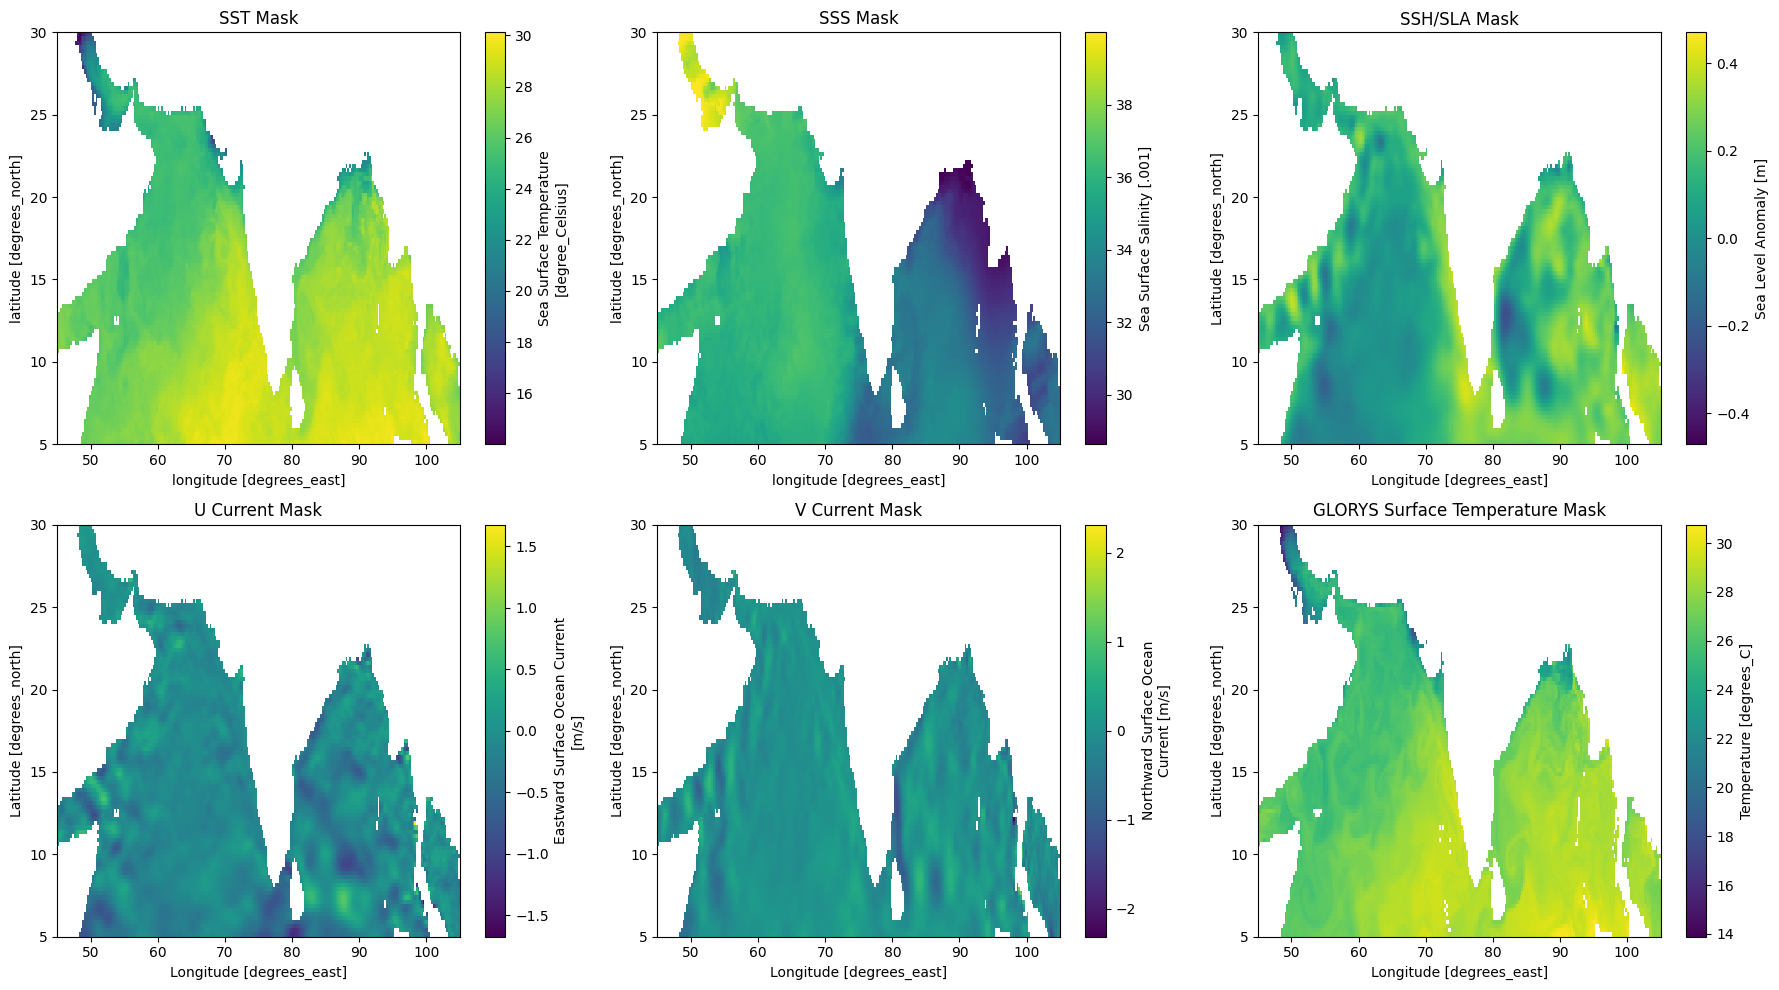

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# First day
time_index = 0

# SST
sst.isel(time=time_index).sea_surface_temperature.plot(
    ax=axes[0, 0],
    cmap="viridis"
)
axes[0, 0].set_title("SST Mask")

# SSS
sss.isel(time=time_index).sea_surface_salinity.plot(
    ax=axes[0, 1],
    cmap="viridis"
)
axes[0, 1].set_title("SSS Mask")

# SLA
ssh.isel(time=time_index).sea_level_anomaly.plot(
    ax=axes[0, 2],
    cmap="viridis"
)
axes[0, 2].set_title("SSH/SLA Mask")

# U current
currents.isel(time=time_index).uo.plot(
    ax=axes[1, 0],
    cmap="viridis"
)
axes[1, 0].set_title("U Current Mask")

# V current
currents.isel(time=time_index).vo.plot(
    ax=axes[1, 1],
    cmap="viridis"
)
axes[1, 1].set_title("V Current Mask")

# GLORYS surface temperature
glorys.isel(time=time_index, depth=0).thetao.plot(
    ax=axes[1, 2],
    cmap="viridis"
)
axes[1, 2].set_title("GLORYS Surface Temperature Mask")

plt.tight_layout()
plt.show()

In [7]:
print("=" * 75)
print("CELL-BY-CELL MASK COMPARISON")
print("=" * 75)

# ---------------------------------------------------------
# Create valid-data masks for the first day
# ---------------------------------------------------------

sst_mask = sst["sea_surface_temperature"].isel(time=0).notnull()
sss_mask = sss["sea_surface_salinity"].isel(time=0).notnull()
ssh_mask = ssh["sea_level_anomaly"].isel(time=0).notnull()
uo_mask = currents["uo"].isel(time=0).notnull()
vo_mask = currents["vo"].isel(time=0).notnull()
glorys_mask = glorys["thetao"].isel(time=0, depth=0).notnull()


# ---------------------------------------------------------
# Compare every dataset with SST
# ---------------------------------------------------------

masks = {
    "SSS": sss_mask,
    "SSH/SLA": ssh_mask,
    "U Current": uo_mask,
    "V Current": vo_mask,
    "GLORYS Surface": glorys_mask
}

print("\nComparison against SST mask:")
print("-" * 60)

for name, mask in masks.items():

    different_cells = int((mask != sst_mask).sum().compute())

    total_cells = sst_mask.size

    percentage = (different_cells / total_cells) * 100

    print(
        f"{name:18s} | "
        f"Different cells: {different_cells:6d} | "
        f"Difference: {percentage:.4f}%"
    )


# ---------------------------------------------------------
# Number of valid ocean cells
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("VALID OCEAN CELLS — FIRST DAY")
print("=" * 75)

all_masks = {
    "SST": sst_mask,
    "SSS": sss_mask,
    "SSH/SLA": ssh_mask,
    "U Current": uo_mask,
    "V Current": vo_mask,
    "GLORYS Surface": glorys_mask
}

for name, mask in all_masks.items():

    valid_cells = int(mask.sum().compute())

    print(
        f"{name:18s} : "
        f"{valid_cells:,} / {mask.size:,}"
    )

CELL-BY-CELL MASK COMPARISON

Comparison against SST mask:
------------------------------------------------------------
SSS                | Different cells:    187 | Difference: 0.7792%
SSH/SLA            | Different cells:     80 | Difference: 0.3333%
U Current          | Different cells:    106 | Difference: 0.4417%
V Current          | Different cells:    106 | Difference: 0.4417%
GLORYS Surface     | Different cells:    171 | Difference: 0.7125%

VALID OCEAN CELLS — FIRST DAY
SST                : 11,863 / 24,000
SSS                : 11,688 / 24,000
SSH/SLA            : 11,887 / 24,000
U Current          : 11,873 / 24,000
V Current          : 11,873 / 24,000
GLORYS Surface     : 11,722 / 24,000


In [8]:
print("=" * 75)
print("VARIABLE METADATA AND UNITS")
print("=" * 75)

for name, ds in datasets.items():

    print("\n" + "=" * 75)
    print(name)
    print("=" * 75)

    for var_name in ds.data_vars:

        var = ds[var_name]

        print(f"\nVariable: {var_name}")
        print(f"  Dimensions : {var.dims}")
        print(f"  Shape      : {var.shape}")
        print(f"  Data type  : {var.dtype}")

        print(f"  Units      : {var.attrs.get('units', 'NOT SPECIFIED')}")
        print(f"  Long name  : {var.attrs.get('long_name', 'NOT SPECIFIED')}")
        print(f"  Standard   : {var.attrs.get('standard_name', 'NOT SPECIFIED')}")

        # Print remaining attributes if available
        other_attrs = {
            k: v for k, v in var.attrs.items()
            if k not in ['units', 'long_name', 'standard_name']
        }

        if other_attrs:
            print("  Other attributes:")
            for key, value in other_attrs.items():
                print(f"    {key}: {value}")

VARIABLE METADATA AND UNITS

SST

Variable: sea_surface_temperature
  Dimensions : ('time', 'latitude', 'longitude')
  Shape      : (455, 100, 240)
  Data type  : float64
  Units      : degree_Celsius
  Long name  : Sea Surface Temperature
  Standard   : sea_surface_temperature
  Other attributes:
    comment:  OSTIA foundation SST
    reference: C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017
    source: AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0
    valid_max: 4500
    valid_min: -300

SSS

Variable: sea_surface_salinity
  Dim

In [9]:
print("=" * 75)
print("SST AND SSS METADATA")
print("=" * 75)

for name, ds in {
    "SST": sst,
    "SSS": sss
}.items():

    print("\n" + "=" * 75)
    print(name)
    print("=" * 75)

    for var_name in ds.data_vars:

        var = ds[var_name]

        print(f"\nVariable: {var_name}")
        print(f"  Dimensions : {var.dims}")
        print(f"  Shape      : {var.shape}")
        print(f"  Data type  : {var.dtype}")
        print(f"  Units      : {var.attrs.get('units', 'NOT SPECIFIED')}")
        print(f"  Long name  : {var.attrs.get('long_name', 'NOT SPECIFIED')}")
        print(f"  Standard   : {var.attrs.get('standard_name', 'NOT SPECIFIED')}")

        print("\n  All attributes:")
        for key, value in var.attrs.items():
            print(f"    {key}: {value}")

SST AND SSS METADATA

SST

Variable: sea_surface_temperature
  Dimensions : ('time', 'latitude', 'longitude')
  Shape      : (455, 100, 240)
  Data type  : float64
  Units      : degree_Celsius
  Long name  : Sea Surface Temperature
  Standard   : sea_surface_temperature

  All attributes:
    comment:  OSTIA foundation SST
    long_name: Sea Surface Temperature
    reference: C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017
    source: AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0
    standard_name: sea_surface_temperature
    unit

In [10]:
print("=" * 75)
print("ACTUAL PHYSICAL RANGE CHECK")
print("=" * 75)

variables_to_check = {
    "SST": (sst, "sea_surface_temperature"),
    "SSS": (sss, "sea_surface_salinity"),
    "SSH/SLA": (ssh, "sea_level_anomaly"),
    "U Current": (currents, "uo"),
    "V Current": (currents, "vo"),
    "GLORYS": (glorys, "thetao"),
}

for name, (ds, var_name) in variables_to_check.items():

    data = ds[var_name]

    valid = data.where(data.notnull())

    minimum = float(valid.min().compute())
    maximum = float(valid.max().compute())
    mean = float(valid.mean().compute())
    median = float(valid.median().compute())

    print(f"\n{name}")
    print("-" * 55)
    print(f"Variable : {var_name}")
    print(f"Min      : {minimum:.4f}")
    print(f"Max      : {maximum:.4f}")
    print(f"Mean     : {mean:.4f}")
    print(f"Median   : {median:.4f}")

ACTUAL PHYSICAL RANGE CHECK

SST
-------------------------------------------------------
Variable : sea_surface_temperature
Min      : 13.0400
Max      : 36.2500
Mean     : 28.1777
Median   : 28.5200

SSS
-------------------------------------------------------
Variable : sea_surface_salinity
Min      : 26.7928
Max      : 40.0000
Mean     : 34.5622
Median   : 35.2229

SSH/SLA
-------------------------------------------------------
Variable : sea_level_anomaly
Min      : -0.5592
Max      : 0.8532
Mean     : 0.1459
Median   : 0.1491

U Current
-------------------------------------------------------
Variable : uo
Min      : -2.9720
Max      : 2.8810
Mean     : 0.0178
Median   : 0.0070

V Current
-------------------------------------------------------
Variable : vo
Min      : -2.3280
Max      : 2.9560
Mean     : 0.0072
Median   : 0.0000

GLORYS
-------------------------------------------------------
Variable : thetao
Min      : 5.1941
Max      : 36.2173
Mean     : 7.8814
Median   : 24.6257


In [11]:
print("=" * 75)
print("TIME AXIS QUALITY CHECK")
print("=" * 75)

for name, ds in datasets.items():

    time = pd.DatetimeIndex(ds.time.values)

    # Differences between consecutive dates
    differences = time.to_series().diff().dropna()

    # Number of duplicate timestamps
    duplicate_count = time.duplicated().sum()

    # Number of unique time intervals
    unique_intervals = differences.unique()

    print(f"\n{name}")
    print("-" * 60)

    print("Start date        :", time[0])
    print("End date          :", time[-1])
    print("Number of dates   :", len(time))
    print("Unique dates      :", time.nunique())
    print("Duplicate dates   :", duplicate_count)

    print("Time intervals    :",
          sorted(set(str(x) for x in unique_intervals)))

    # Check expected daily sequence
    expected = pd.date_range(
        start=time[0],
        end=time[-1],
        freq="D"
    )

    missing_dates = expected.difference(time)

    print("Missing dates     :", len(missing_dates))

    if len(missing_dates) > 0:
        print("Missing date list :", missing_dates.tolist())

    if (
        len(time) == 455
        and duplicate_count == 0
        and len(missing_dates) == 0
        and len(time) == len(expected)
    ):
        print("STATUS            : ✅ Continuous daily time series")
    else:
        print("STATUS            : ⚠️ Needs investigation")

TIME AXIS QUALITY CHECK

SST
------------------------------------------------------------
Start date        : 2025-01-01 00:00:00
End date          : 2026-03-31 00:00:00
Number of dates   : 455
Unique dates      : 455
Duplicate dates   : 0
Time intervals    : ['1 days 00:00:00']
Missing dates     : 0
STATUS            : ✅ Continuous daily time series

SSS
------------------------------------------------------------
Start date        : 2025-01-01 00:00:00
End date          : 2026-03-31 00:00:00
Number of dates   : 455
Unique dates      : 455
Duplicate dates   : 0
Time intervals    : ['1 days 00:00:00']
Missing dates     : 0
STATUS            : ✅ Continuous daily time series

SSH_SLA
------------------------------------------------------------
Start date        : 2025-01-01 00:00:00
End date          : 2026-03-31 00:00:00
Number of dates   : 455
Unique dates      : 455
Duplicate dates   : 0
Time intervals    : ['1 days 00:00:00']
Missing dates     : 0
STATUS            : ✅ Continuous dai

In [12]:
print("=" * 75)
print("COMMON VALID OCEAN MASK")
print("=" * 75)

# First day
sst_valid = sst["sea_surface_temperature"].isel(time=0).notnull()
sss_valid = sss["sea_surface_salinity"].isel(time=0).notnull()
sla_valid = ssh["sea_level_anomaly"].isel(time=0).notnull()
uo_valid = currents["uo"].isel(time=0).notnull()
vo_valid = currents["vo"].isel(time=0).notnull()
glorys_valid = glorys["thetao"].isel(time=0, depth=0).notnull()

# Common valid mask
common_mask = (
    sst_valid
    & sss_valid
    & sla_valid
    & uo_valid
    & vo_valid
    & glorys_valid
)

total_cells = common_mask.size
common_valid = int(common_mask.sum().compute())
common_invalid = total_cells - common_valid

print(f"\nTotal grid cells       : {total_cells:,}")
print(f"Common valid cells     : {common_valid:,}")
print(f"Common invalid cells   : {common_invalid:,}")
print(f"Common valid %         : {common_valid / total_cells * 100:.2f}%")
print(f"Common invalid %       : {common_invalid / total_cells * 100:.2f}%")

# ---------------------------------------------------------
# Compare common mask with each individual mask
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("COMMON MASK COMPARISON")
print("=" * 75)

individual_masks = {
    "SST": sst_valid,
    "SSS": sss_valid,
    "SSH/SLA": sla_valid,
    "U Current": uo_valid,
    "V Current": vo_valid,
    "GLORYS Surface": glorys_valid,
}

for name, mask in individual_masks.items():

    valid_cells = int(mask.sum().compute())
    lost_cells = valid_cells - common_valid

    print(
        f"{name:18s} | "
        f"Valid: {valid_cells:,} | "
        f"Excluded by common mask: {lost_cells:,}"
    )

COMMON VALID OCEAN MASK

Total grid cells       : 24,000
Common valid cells     : 11,613
Common invalid cells   : 12,387
Common valid %         : 48.39%
Common invalid %       : 51.61%

COMMON MASK COMPARISON
SST                | Valid: 11,863 | Excluded by common mask: 250
SSS                | Valid: 11,688 | Excluded by common mask: 75
SSH/SLA            | Valid: 11,887 | Excluded by common mask: 274
U Current          | Valid: 11,873 | Excluded by common mask: 260
V Current          | Valid: 11,873 | Excluded by common mask: 260
GLORYS Surface     | Valid: 11,722 | Excluded by common mask: 109


In [13]:
print("=" * 75)
print("COMMON MASK STABILITY ACROSS ALL DAYS")
print("=" * 75)

# Validity for every dataset
sst_valid_all = sst["sea_surface_temperature"].notnull()
sss_valid_all = sss["sea_surface_salinity"].notnull()
sla_valid_all = ssh["sea_level_anomaly"].notnull()
uo_valid_all = currents["uo"].notnull()
vo_valid_all = currents["vo"].notnull()
glorys_valid_all = glorys["thetao"].isel(depth=0).notnull()

# Common valid mask for every day
common_valid_all = (
    sst_valid_all
    & sss_valid_all
    & sla_valid_all
    & uo_valid_all
    & vo_valid_all
    & glorys_valid_all
)

# Number of valid days for each grid cell
valid_days_per_cell = common_valid_all.sum(dim="time").compute()

total_cells = valid_days_per_cell.size
days = len(sst.time)

always_valid = int((valid_days_per_cell == days).sum())
never_valid = int((valid_days_per_cell == 0).sum())

print(f"\nTotal grid cells                 : {total_cells:,}")
print(f"Total days                       : {days}")
print(f"Cells valid on ALL {days} days     : {always_valid:,}")
print(f"Cells valid on NO days           : {never_valid:,}")

print("\nValid days per grid cell:")
print(f"Minimum valid days               : {int(valid_days_per_cell.min())}")
print(f"Maximum valid days               : {int(valid_days_per_cell.max())}")
print(f"Mean valid days                  : {float(valid_days_per_cell.mean()):.2f}")
print(f"Median valid days                : {float(valid_days_per_cell.median()):.2f}")

print("\nPercentage of cells:")
print(
    f"Always valid                     : "
    f"{always_valid / total_cells * 100:.2f}%"
)

print(
    f"Never valid                      : "
    f"{never_valid / total_cells * 100:.2f}%"
)

# Distribution
print("\n" + "=" * 75)
print("VALID-DAY DISTRIBUTION")
print("=" * 75)

for threshold in [1, 30, 90, 180, 365, 455]:
    count = int((valid_days_per_cell >= threshold).sum())
    print(
        f"Cells valid >= {threshold:3d} days       : "
        f"{count:,} ({count / total_cells * 100:.2f}%)"
    )


COMMON MASK STABILITY ACROSS ALL DAYS

Total grid cells                 : 24,000
Total days                       : 455
Cells valid on ALL 455 days     : 11,613
Cells valid on NO days           : 12,387

Valid days per grid cell:
Minimum valid days               : 0
Maximum valid days               : 455
Mean valid days                  : 220.16
Median valid days                : 0.00

Percentage of cells:
Always valid                     : 48.39%
Never valid                      : 51.61%

VALID-DAY DISTRIBUTION
Cells valid >=   1 days       : 11,613 (48.39%)
Cells valid >=  30 days       : 11,613 (48.39%)
Cells valid >=  90 days       : 11,613 (48.39%)
Cells valid >= 180 days       : 11,613 (48.39%)
Cells valid >= 365 days       : 11,613 (48.39%)
Cells valid >= 455 days       : 11,613 (48.39%)


In [14]:
print("=" * 75)
print("VERIFY DATA COMPLETENESS INSIDE COMMON OCEAN MASK")
print("=" * 75)

# Static common mask from CELL 13
static_common_mask = valid_days_per_cell == len(sst.time)

# Convert to 2D (latitude, longitude)
static_common_mask = static_common_mask.astype(bool)

datasets_to_check = {
    "SST": sst["sea_surface_temperature"],
    "SSS": sss["sea_surface_salinity"],
    "SSH/SLA": ssh["sea_level_anomaly"],
    "U Current": currents["uo"],
    "V Current": currents["vo"],
    "GLORYS Surface": glorys["thetao"].isel(depth=0)
}

print(f"\nCommon ocean cells: {int(static_common_mask.sum())}")

print("\n" + "-" * 75)

for name, data in datasets_to_check.items():

    # Check NaNs only inside the common ocean mask
    valid_region = data.where(static_common_mask)

    nan_count = int(valid_region.isnull().sum().compute())
    total_values = int(valid_region.size)

    print(
        f"{name:18s} | "
        f"NaNs inside common mask: {nan_count:,}"
    )

print("\n" + "=" * 75)
print("CHECK COMPLETE")
print("=" * 75)

VERIFY DATA COMPLETENESS INSIDE COMMON OCEAN MASK

Common ocean cells: 11613

---------------------------------------------------------------------------
SST                | NaNs inside common mask: 5,636,085
SSS                | NaNs inside common mask: 5,636,085
SSH/SLA            | NaNs inside common mask: 5,636,085
U Current          | NaNs inside common mask: 5,636,085
V Current          | NaNs inside common mask: 5,636,085
GLORYS Surface     | NaNs inside common mask: 5,636,085

CHECK COMPLETE


In [15]:
print("=" * 75)
print("CORRECTED DATA COMPLETENESS CHECK")
print("=" * 75)

datasets_to_check = {
    "SST": sst["sea_surface_temperature"],
    "SSS": sss["sea_surface_salinity"],
    "SSH/SLA": ssh["sea_level_anomaly"],
    "U Current": currents["uo"],
    "V Current": currents["vo"],
    "GLORYS Surface": glorys["thetao"].isel(depth=0)
}

print(f"\nCommon ocean cells: {int(static_common_mask.sum())}")
print(f"Number of days   : {len(sst.time)}")

print("\n" + "-" * 75)

for name, data in datasets_to_check.items():

    # NaNs that occur ONLY inside the common ocean mask
    ocean_nan = data.isnull() & static_common_mask

    nan_count = int(ocean_nan.sum().compute())

    # Total expected ocean values
    ocean_cells = int(static_common_mask.sum())
    expected_values = ocean_cells * len(sst.time)

    valid_count = expected_values - nan_count

    print(
        f"{name:18s} | "
        f"Valid: {valid_count:,} | "
        f"NaNs: {nan_count:,} | "
        f"Expected: {expected_values:,}"
    )

print("\n" + "=" * 75)
print("INTERPRETATION")
print("=" * 75)

print("""
NaNs should ideally be 0 for all datasets inside the
common ocean mask.

The land-region NaNs are intentionally excluded from this check.
""")

CORRECTED DATA COMPLETENESS CHECK

Common ocean cells: 11613
Number of days   : 455

---------------------------------------------------------------------------
SST                | Valid: 5,283,915 | NaNs: 0 | Expected: 5,283,915
SSS                | Valid: 5,283,915 | NaNs: 0 | Expected: 5,283,915
SSH/SLA            | Valid: 5,283,915 | NaNs: 0 | Expected: 5,283,915
U Current          | Valid: 5,283,915 | NaNs: 0 | Expected: 5,283,915
V Current          | Valid: 5,283,915 | NaNs: 0 | Expected: 5,283,915
GLORYS Surface     | Valid: 5,283,915 | NaNs: 0 | Expected: 5,283,915

INTERPRETATION

NaNs should ideally be 0 for all datasets inside the
common ocean mask.

The land-region NaNs are intentionally excluded from this check.



In [16]:
print("=" * 75)
print("GLORYS TARGET VALIDATION — ALL 15 DEPTHS")
print("=" * 75)

depths = glorys["depth"].values

# Common ocean mask from the surface
ocean_mask = static_common_mask

print(f"\nNumber of GLORYS depths: {len(depths)}")
print(f"Depths: {depths.tolist()}")

print("\n" + "-" * 90)
print(
    f"{'Depth (m)':>12s} | "
    f"{'Valid':>15s} | "
    f"{'NaNs':>15s} | "
    f"{'Min (°C)':>12s} | "
    f"{'Max (°C)':>12s} | "
    f"{'Mean (°C)':>12s}"
)
print("-" * 90)

for i, depth in enumerate(depths):

    temp = glorys["thetao"].isel(depth=i)

    # Check only cells inside the common ocean mask
    ocean_values = temp.where(ocean_mask)

    valid_mask = (~temp.isnull()) & ocean_mask

    valid_count = int(valid_mask.sum().compute())
    total_ocean_values = int(ocean_mask.sum()) * len(glorys.time)

    nan_count = total_ocean_values - valid_count

    min_val = float(ocean_values.min().compute())
    max_val = float(ocean_values.max().compute())
    mean_val = float(ocean_values.mean().compute())

    print(
        f"{float(depth):12.1f} | "
        f"{valid_count:15,} | "
        f"{nan_count:15,} | "
        f"{min_val:12.3f} | "
        f"{max_val:12.3f} | "
        f"{mean_val:12.3f}"
    )

print("\n" + "=" * 75)
print("DEPTH VALIDATION COMPLETE")
print("=" * 75)

GLORYS TARGET VALIDATION — ALL 15 DEPTHS

Number of GLORYS depths: 15
Depths: [0.0, 5.0, 10.0, 20.0, 30.0, 50.0, 75.0, 100.0, 125.0, 150.0, 200.0, 300.0, 500.0, 700.0, 1000.0]

------------------------------------------------------------------------------------------
   Depth (m) |           Valid |            NaNs |     Min (°C) |     Max (°C) |    Mean (°C)
------------------------------------------------------------------------------------------
         0.0 |       5,283,915 |               0 |       12.870 |       36.179 |       28.939
         5.0 |       5,283,915 |               0 |       13.532 |       36.069 |       28.843
        10.0 |       5,158,790 |         125,125 |       15.266 |       35.649 |       28.725
        20.0 |       5,025,930 |         257,985 |       15.615 |       35.160 |       28.542
        30.0 |       4,879,875 |         404,040 |       15.001 |       34.365 |       28.214
        50.0 |       4,675,580 |         608,335 |       14.587 |       33.42

In [17]:
print("=" * 75)
print("GLORYS DEPTH COVERAGE")
print("=" * 75)

common_ocean_cells = int(static_common_mask.sum())

print(f"\nCommon surface ocean cells : {common_ocean_cells:,}")
print(f"Total days                  : {len(glorys.time)}")

print("\n" + "-" * 75)
print(
    f"{'Depth (m)':>12s} | "
    f"{'Valid Cells/Days':>18s} | "
    f"{'Coverage':>12s} | "
    f"{'Missing':>12s}"
)
print("-" * 75)

for i, depth in enumerate(glorys["depth"].values):

    temp = glorys["thetao"].isel(depth=i)

    valid = ((~temp.isnull()) & static_common_mask)

    valid_count = int(valid.sum().compute())

    total_possible = common_ocean_cells * len(glorys.time)

    coverage = valid_count / total_possible * 100
    missing = 100 - coverage

    print(
        f"{float(depth):12.1f} | "
        f"{valid_count:18,} | "
        f"{coverage:11.2f}% | "
        f"{missing:11.2f}%"
    )

print("\n" + "=" * 75)
print("DEPTH COVERAGE CHECK COMPLETE")
print("=" * 75)

GLORYS DEPTH COVERAGE

Common surface ocean cells : 11,613
Total days                  : 455

---------------------------------------------------------------------------
   Depth (m) |   Valid Cells/Days |     Coverage |      Missing
---------------------------------------------------------------------------
         0.0 |          5,283,915 |      100.00% |        0.00%
         5.0 |          5,283,915 |      100.00% |        0.00%
        10.0 |          5,158,790 |       97.63% |        2.37%
        20.0 |          5,025,930 |       95.12% |        4.88%
        30.0 |          4,879,875 |       92.35% |        7.65%
        50.0 |          4,675,580 |       88.49% |       11.51%
        75.0 |          4,484,025 |       84.86% |       15.14%
       100.0 |          4,383,470 |       82.96% |       17.04%
       125.0 |          4,358,900 |       82.49% |       17.51%
       150.0 |          4,340,245 |       82.14% |       17.86%
       200.0 |          4,299,295 |       81.37% |

In [18]:
print("=" * 75)
print("GLORYS DEPTH MASK STABILITY")
print("=" * 75)

print("\nChecking whether missing regions change over time...\n")

for i, depth in enumerate(glorys["depth"].values):

    temp = glorys["thetao"].isel(depth=i)

    # Validity at every time and grid cell
    valid = (~temp.isnull()) & static_common_mask

    # Number of valid days for each spatial cell
    valid_days = valid.sum(dim="time").compute()

    total_days = len(glorys.time)

    always_valid = int((valid_days == total_days).sum())
    never_valid = int((valid_days == 0).sum())
    changing = int(
        ((valid_days > 0) & (valid_days < total_days)).sum()
    )

    print(
        f"Depth {float(depth):6.1f} m | "
        f"Always valid: {always_valid:6,} | "
        f"Never valid: {never_valid:6,} | "
        f"Changing: {changing:6,}"
    )

print("\n" + "=" * 75)
print("MASK STABILITY CHECK COMPLETE")
print("=" * 75)

GLORYS DEPTH MASK STABILITY

Checking whether missing regions change over time...

Depth    0.0 m | Always valid: 11,613 | Never valid: 12,387 | Changing:      0
Depth    5.0 m | Always valid: 11,613 | Never valid: 12,387 | Changing:      0
Depth   10.0 m | Always valid: 11,338 | Never valid: 12,662 | Changing:      0
Depth   20.0 m | Always valid: 11,046 | Never valid: 12,954 | Changing:      0
Depth   30.0 m | Always valid: 10,725 | Never valid: 13,275 | Changing:      0
Depth   50.0 m | Always valid: 10,276 | Never valid: 13,724 | Changing:      0
Depth   75.0 m | Always valid:  9,855 | Never valid: 14,145 | Changing:      0
Depth  100.0 m | Always valid:  9,634 | Never valid: 14,366 | Changing:      0
Depth  125.0 m | Always valid:  9,580 | Never valid: 14,420 | Changing:      0
Depth  150.0 m | Always valid:  9,539 | Never valid: 14,461 | Changing:      0
Depth  200.0 m | Always valid:  9,449 | Never valid: 14,551 | Changing:      0
Depth  300.0 m | Always valid:  9,376 | Never va

In [19]:
print("=" * 75)
print("INPUT FEATURE STATISTICS")
print("=" * 75)

features = {
    "SST": sst["sea_surface_temperature"],
    "SSS": sss["sea_surface_salinity"],
    "SSH/SLA": ssh["sea_level_anomaly"],
    "U Current": currents["uo"],
    "V Current": currents["vo"]
}

print("\nStatistics inside the common ocean mask:")
print("-" * 85)

print(
    f"{'Feature':<15s} | "
    f"{'Min':>12s} | "
    f"{'Max':>12s} | "
    f"{'Mean':>12s} | "
    f"{'Std':>12s}"
)

print("-" * 85)

for name, data in features.items():

    masked_data = data.where(static_common_mask)

    min_val = float(masked_data.min().compute())
    max_val = float(masked_data.max().compute())
    mean_val = float(masked_data.mean().compute())
    std_val = float(masked_data.std().compute())

    print(
        f"{name:<15s} | "
        f"{min_val:12.4f} | "
        f"{max_val:12.4f} | "
        f"{mean_val:12.4f} | "
        f"{std_val:12.4f}"
    )

print("\n" + "=" * 75)
print("INPUT FEATURE STATISTICS COMPLETE")
print("=" * 75)

INPUT FEATURE STATISTICS

Statistics inside the common ocean mask:
-------------------------------------------------------------------------------------
Feature         |          Min |          Max |         Mean |          Std
-------------------------------------------------------------------------------------
SST             |      13.0400 |      36.2500 |      28.1880 |       1.8676
SSS             |      26.7928 |      40.0000 |      34.5633 |       2.0564
SSH/SLA         |      -0.5188 |       0.8532 |       0.1460 |       0.1028
U Current       |      -2.9720 |       2.7840 |       0.0178 |       0.2796
V Current       |      -2.3280 |       2.9560 |       0.0071 |       0.2277

INPUT FEATURE STATISTICS COMPLETE


In [20]:
print("=" * 75)
print("FINAL INPUT DIMENSION & COORDINATE CHECK")
print("=" * 75)

datasets_to_check = {
    "SST": sst["sea_surface_temperature"],
    "SSS": sss["sea_surface_salinity"],
    "SSH/SLA": ssh["sea_level_anomaly"],
    "U Current": currents["uo"],
    "V Current": currents["vo"],
}

for name, data in datasets_to_check.items():

    print(f"\n{name}")
    print(f"  Dimensions : {data.dims}")
    print(f"  Shape      : {data.shape}")
    print(f"  Dtype      : {data.dtype}")

print("\n" + "=" * 75)
print("TARGET")
print("=" * 75)

target = glorys["thetao"]

print(f"Dimensions : {target.dims}")
print(f"Shape      : {target.shape}")
print(f"Dtype      : {target.dtype}")

print("\n" + "=" * 75)
print("COORDINATE CHECK")
print("=" * 75)

reference = sst["sea_surface_temperature"]

for name, data in datasets_to_check.items():

    same_time = np.array_equal(
        data["time"].values,
        reference["time"].values
    )

    same_lat = np.array_equal(
        data["latitude"].values,
        reference["latitude"].values
    )

    same_lon = np.array_equal(
        data["longitude"].values,
        reference["longitude"].values
    )

    print(
        f"{name:12s} | "
        f"Time: {same_time} | "
        f"Lat: {same_lat} | "
        f"Lon: {same_lon}"
    )

print("\nTARGET vs INPUT GRID")

print(
    "Time:",
    np.array_equal(
        target["time"].values,
        reference["time"].values
    )
)

print(
    "Lat :",
    np.array_equal(
        target["latitude"].values,
        reference["latitude"].values
    )
)

print(
    "Lon :",
    np.array_equal(
        target["longitude"].values,
        reference["longitude"].values
    )
)

print(
    "Depths:",
    target["depth"].values.tolist()
)

print("\n" + "=" * 75)
print("DIMENSION & COORDINATE CHECK COMPLETE")
print("=" * 75)

FINAL INPUT DIMENSION & COORDINATE CHECK

SST
  Dimensions : ('time', 'latitude', 'longitude')
  Shape      : (455, 100, 240)
  Dtype      : float64

SSS
  Dimensions : ('time', 'latitude', 'longitude')
  Shape      : (455, 100, 240)
  Dtype      : float64

SSH/SLA
  Dimensions : ('time', 'latitude', 'longitude')
  Shape      : (455, 100, 240)
  Dtype      : float64

U Current
  Dimensions : ('time', 'latitude', 'longitude')
  Shape      : (455, 100, 240)
  Dtype      : float64

V Current
  Dimensions : ('time', 'latitude', 'longitude')
  Shape      : (455, 100, 240)
  Dtype      : float64

TARGET
Dimensions : ('time', 'depth', 'latitude', 'longitude')
Shape      : (455, 15, 100, 240)
Dtype      : float32

COORDINATE CHECK
SST          | Time: True | Lat: True | Lon: True
SSS          | Time: True | Lat: True | Lon: True
SSH/SLA      | Time: True | Lat: True | Lon: True
U Current    | Time: True | Lat: True | Lon: True
V Current    | Time: True | Lat: True | Lon: True

TARGET vs INPUT 

In [21]:
print("=" * 75)
print("32 × 32 SPATIAL PATCH SETUP")
print("=" * 75)

PATCH_SIZE = 32
HALF = PATCH_SIZE // 2

n_lat = len(sst.latitude)
n_lon = len(sst.longitude)

print(f"\nGrid resolution       : 0.25° × 0.25°")
print(f"Grid shape            : {n_lat} × {n_lon}")
print(f"Patch size            : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"Patch physical size   : {PATCH_SIZE * 0.25:.2f}° × {PATCH_SIZE * 0.25:.2f}°")

print("\n" + "-" * 75)

# Valid center indices where a complete 32×32 patch fits
lat_start = HALF
lat_end = n_lat - HALF

lon_start = HALF
lon_end = n_lon - HALF

valid_center_lat = np.arange(lat_start, lat_end)
valid_center_lon = np.arange(lon_start, lon_end)

print(f"Valid center latitude indices  : {len(valid_center_lat)}")
print(f"Valid center longitude indices : {len(valid_center_lon)}")

potential_centers = (
    len(valid_center_lat) *
    len(valid_center_lon)
)

print(f"\nPotential patch centers/day    : {potential_centers:,}")
print(f"Potential patches, 455 days   : {potential_centers * len(sst.time):,}")

print("\n" + "-" * 75)

print("Latitude coverage:")
print(
    f"  {float(sst.latitude.values[lat_start]):.3f}°N "
    f"to "
    f"{float(sst.latitude.values[lat_end - 1]):.3f}°N"
)

print("Longitude coverage:")
print(
    f"  {float(sst.longitude.values[lon_start]):.3f}°E "
    f"to "
    f"{float(sst.longitude.values[lon_end - 1]):.3f}°E"
)

print("\n" + "=" * 75)
print("PATCH SETUP COMPLETE")
print("=" * 75)

32 × 32 SPATIAL PATCH SETUP

Grid resolution       : 0.25° × 0.25°
Grid shape            : 100 × 240
Patch size            : 32 × 32
Patch physical size   : 8.00° × 8.00°

---------------------------------------------------------------------------
Valid center latitude indices  : 68
Valid center longitude indices : 208

Potential patch centers/day    : 14,144
Potential patches, 455 days   : 6,435,520

---------------------------------------------------------------------------
Latitude coverage:
  9.125°N to 25.875°N
Longitude coverage:
  49.125°E to 100.875°E

PATCH SETUP COMPLETE


In [22]:
print("=" * 75)
print("32 × 32 PATCH OCEAN COVERAGE")
print("=" * 75)

PATCH_SIZE = 32
HALF = PATCH_SIZE // 2

# Static common ocean mask
mask = static_common_mask.values

# Valid center ranges
lat_centers = range(HALF, n_lat - HALF)
lon_centers = range(HALF, n_lon - HALF)

coverage_list = []

for i in lat_centers:
    for j in lon_centers:

        patch = mask[
            i - HALF:i + HALF,
            j - HALF:j + HALF
        ]

        ocean_fraction = patch.mean()

        coverage_list.append(ocean_fraction)

coverage = np.array(coverage_list)

print(f"\nTotal possible patches/day : {len(coverage):,}")

print("\nOcean coverage statistics:")
print("-" * 75)

print(f"Minimum coverage           : {coverage.min() * 100:.2f}%")
print(f"Maximum coverage           : {coverage.max() * 100:.2f}%")
print(f"Mean coverage              : {coverage.mean() * 100:.2f}%")
print(f"Median coverage            : {np.median(coverage) * 100:.2f}%")

print("\n" + "-" * 75)
print("PATCHES BY OCEAN COVERAGE")
print("-" * 75)

for threshold in [25, 50, 75, 90, 95, 100]:

    count = int((coverage >= threshold / 100).sum())

    print(
        f"Coverage >= {threshold:3d}% : "
        f"{count:,} patches/day "
        f"({count / len(coverage) * 100:.2f}%)"
    )

print("\n" + "=" * 75)
print("PATCH OCEAN COVERAGE CHECK COMPLETE")
print("=" * 75)

32 × 32 PATCH OCEAN COVERAGE

Total possible patches/day : 14,144

Ocean coverage statistics:
---------------------------------------------------------------------------
Minimum coverage           : 0.00%
Maximum coverage           : 100.00%
Mean coverage              : 55.12%
Median coverage            : 57.71%

---------------------------------------------------------------------------
PATCHES BY OCEAN COVERAGE
---------------------------------------------------------------------------
Coverage >=  25% : 10,248 patches/day (72.45%)
Coverage >=  50% : 7,835 patches/day (55.39%)
Coverage >=  75% : 5,391 patches/day (38.12%)
Coverage >=  90% : 3,864 patches/day (27.32%)
Coverage >=  95% : 3,226 patches/day (22.81%)
Coverage >= 100% : 1,396 patches/day (9.87%)

PATCH OCEAN COVERAGE CHECK COMPLETE


In [23]:
print("=" * 75)
print("VALID 32 × 32 PATCH CENTERS + 15-DEPTH TARGET")
print("=" * 75)

PATCH_SIZE = 32
HALF = PATCH_SIZE // 2
MIN_OCEAN_FRACTION = 0.75

mask = static_common_mask.values

valid_centers = []

for i in range(HALF, n_lat - HALF):
    for j in range(HALF, n_lon - HALF):

        patch = mask[
            i - HALF:i + HALF,
            j - HALF:j + HALF
        ]

        ocean_fraction = patch.mean()

        if ocean_fraction >= MIN_OCEAN_FRACTION:
            valid_centers.append((i, j, ocean_fraction))

print(f"\nOcean coverage threshold : {MIN_OCEAN_FRACTION * 100:.0f}%")
print(f"Valid patch centers/day  : {len(valid_centers):,}")

# ------------------------------------------------------------------
# Check which patch centers also have valid GLORYS temperature
# at ALL 15 depths.
# ------------------------------------------------------------------

target_valid_all_depths = (
    ~glorys["thetao"].isnull()
).all(dim="depth")

# Because the GLORYS mask is time-stable, check first day
target_mask = target_valid_all_depths.isel(time=0).values

valid_centers_with_target = []

for i, j, ocean_fraction in valid_centers:

    if target_mask[i, j]:
        valid_centers_with_target.append(
            (i, j, ocean_fraction)
        )

print(
    f"Valid centers with all 15-depth target : "
    f"{len(valid_centers_with_target):,}"
)

print("\n" + "-" * 75)

total_days = len(glorys.time)

print(
    f"Potential samples across {total_days} days : "
    f"{len(valid_centers_with_target) * total_days:,}"
)

print("\n" + "=" * 75)
print("VALID PATCH CENTER CHECK COMPLETE")
print("=" * 75)

VALID 32 × 32 PATCH CENTERS + 15-DEPTH TARGET

Ocean coverage threshold : 75%
Valid patch centers/day  : 5,391
Valid centers with all 15-depth target : 4,996

---------------------------------------------------------------------------
Potential samples across 455 days : 2,273,180

VALID PATCH CENTER CHECK COMPLETE


VALID TRAINING CENTER DISTRIBUTION

Valid centers: 4,996
Latitude range  : 9.125°N to 23.125°N
Longitude range : 51.875°E to 96.375°E
Mean patch ocean coverage : 94.19%
Minimum patch ocean coverage : 75.00%


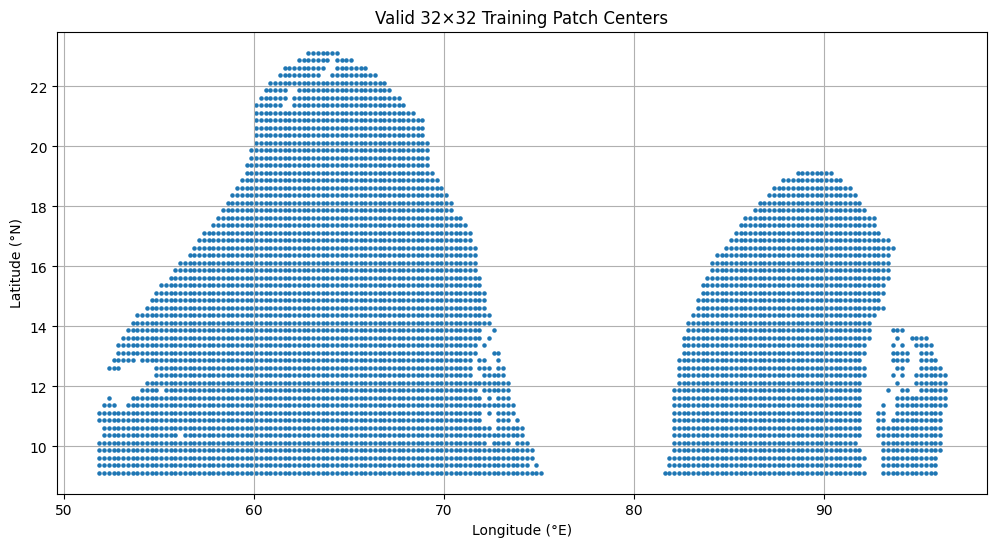


CENTER DISTRIBUTION CHECK COMPLETE


In [24]:
import matplotlib.pyplot as plt

print("=" * 75)
print("VALID TRAINING CENTER DISTRIBUTION")
print("=" * 75)

# Extract latitude/longitude of valid centers
center_latitudes = []
center_longitudes = []
center_coverages = []

for i, j, ocean_fraction in valid_centers_with_target:
    center_latitudes.append(float(sst.latitude.values[i]))
    center_longitudes.append(float(sst.longitude.values[j]))
    center_coverages.append(ocean_fraction)

center_latitudes = np.array(center_latitudes)
center_longitudes = np.array(center_longitudes)
center_coverages = np.array(center_coverages)

print(f"\nValid centers: {len(center_latitudes):,}")

print(
    f"Latitude range  : "
    f"{center_latitudes.min():.3f}°N to "
    f"{center_latitudes.max():.3f}°N"
)

print(
    f"Longitude range : "
    f"{center_longitudes.min():.3f}°E to "
    f"{center_longitudes.max():.3f}°E"
)

print(
    f"Mean patch ocean coverage : "
    f"{center_coverages.mean() * 100:.2f}%"
)

print(
    f"Minimum patch ocean coverage : "
    f"{center_coverages.min() * 100:.2f}%"
)

# Plot valid centers
plt.figure(figsize=(12, 6))

plt.scatter(
    center_longitudes,
    center_latitudes,
    s=5
)

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Valid 32×32 Training Patch Centers")
plt.grid(True)

plt.show()

print("\n" + "=" * 75)
print("CENTER DISTRIBUTION CHECK COMPLETE")
print("=" * 75)

In [25]:
from pathlib import Path
import json
import numpy as np

# ---------------------------------------------------------
# Create directory for processed OceanEmbed data
# ---------------------------------------------------------
processed_dir = Path("processed_oceanembed")
processed_dir.mkdir(exist_ok=True)

# ---------------------------------------------------------
# Save configuration / metadata
# ---------------------------------------------------------
metadata = {
    "project": "OceanEmbed",
    "grid_resolution": "0.25 degree",
    "patch_size": "32x32",
    "patch_physical_size": "8x8 degrees",
    "minimum_ocean_coverage": 0.75,
    "input_channels": [
        "SST",
        "SSS",
        "SSH_SLA",
        "U_current",
        "V_current"
    ],
    "target": "GLORYS_thetao",
    "target_depths_m": [
        0, 5, 10, 20, 30,
        50, 75, 100, 125, 150,
        200, 300, 500, 700, 1000
    ],
    "num_valid_patch_centers": len(valid_centers_with_target),
    "num_grid_latitude": len(sst.latitude),
    "num_grid_longitude": len(sst.longitude),
    "num_days": len(sst.time)
}

with open(processed_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

# ---------------------------------------------------------
# Save the static common ocean mask
# ---------------------------------------------------------
np.save(
    processed_dir / "common_ocean_mask.npy",
    static_common_mask.values.astype(np.uint8)
)

# ---------------------------------------------------------
# Save valid patch centers
# ---------------------------------------------------------
# Format:
# [latitude_index, longitude_index, ocean_coverage_fraction]

valid_centers_array = np.array(
    [(i, j, fraction) for i, j, fraction in valid_centers_with_target],
    dtype=np.float32
)

np.save(
    processed_dir / "valid_patch_centers.npy",
    valid_centers_array
)

# ---------------------------------------------------------
# Save grid coordinates
# ---------------------------------------------------------
np.save(
    processed_dir / "latitude.npy",
    sst.latitude.values
)

np.save(
    processed_dir / "longitude.npy",
    sst.longitude.values
)

np.save(
    processed_dir / "depths.npy",
    glorys.depth.values
)

# ---------------------------------------------------------
# Save time coordinate
# ---------------------------------------------------------
np.save(
    processed_dir / "time.npy",
    sst.time.values
)

# ---------------------------------------------------------
# Print verification
# ---------------------------------------------------------
print("=" * 70)
print("PROCESSED DATA METADATA SAVED")
print("=" * 70)

print(f"\nDirectory:")
print(processed_dir.resolve())

print("\nFiles saved:")

for file in sorted(processed_dir.iterdir()):
    size_kb = file.stat().st_size / 1024
    print(f"  ✅ {file.name:30s} {size_kb:.2f} KB")

print("\nValid patch centers :", len(valid_centers_with_target))
print("Patch size          : 32 × 32")
print("Ocean threshold     : 75%")
print("Grid resolution     : 0.25°")
print("Target depths       : 15")

print("\n" + "=" * 70)
print("SAVE COMPLETE")
print("=" * 70)

PROCESSED DATA METADATA SAVED

Directory:
/content/processed_oceanembed

Files saved:
  ✅ common_ocean_mask.npy          23.56 KB
  ✅ depths.npy                     0.24 KB
  ✅ latitude.npy                   0.91 KB
  ✅ longitude.npy                  2.00 KB
  ✅ metadata.json                  0.65 KB
  ✅ time.npy                       3.68 KB
  ✅ valid_patch_centers.npy        58.67 KB

Valid patch centers : 4996
Patch size          : 32 × 32
Ocean threshold     : 75%
Grid resolution     : 0.25°
Target depths       : 15

SAVE COMPLETE


In [26]:
print("=" * 75)
print("PREPARING PROCESSED DATA FOR SAVING")
print("=" * 75)

# ---------------------------------------------------------
# Create processed dataset
# ---------------------------------------------------------

processed_data = xr.Dataset(
    {
        "SST": sst["sea_surface_temperature"].astype("float32"),
        "SSS": sss["sea_surface_salinity"].astype("float32"),
        "SLA": ssh["sea_level_anomaly"].astype("float32"),
        "U": currents["uo"].astype("float32"),
        "V": currents["vo"].astype("float32"),
        "thetao": glorys["thetao"].astype("float32")
    }
)

# ---------------------------------------------------------
# Add useful attributes
# ---------------------------------------------------------

processed_data["SST"].attrs["description"] = "Sea Surface Temperature"
processed_data["SSS"].attrs["description"] = "Sea Surface Salinity"
processed_data["SLA"].attrs["description"] = "Sea Level Anomaly"
processed_data["U"].attrs["description"] = "Eastward Surface Ocean Current"
processed_data["V"].attrs["description"] = "Northward Surface Ocean Current"
processed_data["thetao"].attrs["description"] = "GLORYS subsurface potential temperature"

processed_data.attrs["project"] = "OceanEmbed"
processed_data.attrs["grid_resolution"] = "0.25 degree"
processed_data.attrs["patch_size"] = "32x32"
processed_data.attrs["minimum_ocean_coverage"] = 0.75

# ---------------------------------------------------------
# Display before saving
# ---------------------------------------------------------

print("\nProcessed dataset:")
print(processed_data)

print("\nVariables:")
for name in processed_data.data_vars:
    print(
        f"  {name:8s} "
        f"shape={processed_data[name].shape} "
        f"dtype={processed_data[name].dtype}"
    )

print("\n" + "=" * 75)
print("READY TO SAVE")
print("=" * 75)

PREPARING PROCESSED DATA FOR SAVING

Processed dataset:
<xarray.Dataset> Size: 874MB
Dimensions:    (time: 455, latitude: 100, longitude: 240, depth: 15)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude   (latitude) float64 800B 5.125 5.375 5.625 ... 29.38 29.62 29.88
  * longitude  (longitude) float64 2kB 45.12 45.38 45.62 ... 104.4 104.6 104.9
  * depth      (depth) float64 120B 0.0 5.0 10.0 20.0 ... 500.0 700.0 1e+03
Data variables:
    SST        (time, latitude, longitude) float32 44MB nan nan nan ... nan nan
    SSS        (time, latitude, longitude) float32 44MB nan nan nan ... nan nan
    SLA        (time, latitude, longitude) float32 44MB nan nan nan ... nan nan
    U          (time, latitude, longitude) float32 44MB nan nan nan ... nan nan
    V          (time, latitude, longitude) float32 44MB nan nan nan ... nan nan
    thetao     (time, depth, latitude, longitude) float32 655MB nan nan ... nan
Attributes:
    project: 

In [27]:
print("=" * 75)
print("SAVING PROCESSED DATA")
print("=" * 75)

output_file = processed_dir / "processed_data.nc"

# Compression settings
encoding = {}

for variable in processed_data.data_vars:
    encoding[variable] = {
        "zlib": True,
        "complevel": 4,
        "dtype": "float32"
    }

# Save
processed_data.to_netcdf(
    output_file,
    encoding=encoding
)

# ---------------------------------------------------------
# Verify file
# ---------------------------------------------------------

file_size_mb = output_file.stat().st_size / (1024 ** 2)

print("\n✅ Processed dataset saved successfully!")
print(f"\nFile:")
print(output_file.resolve())

print(f"\nFile size: {file_size_mb:.2f} MB")

print("\n" + "=" * 75)
print("SAVE COMPLETE")
print("=" * 75)

SAVING PROCESSED DATA

✅ Processed dataset saved successfully!

File:
/content/processed_oceanembed/processed_data.nc

File size: 279.55 MB

SAVE COMPLETE


In [28]:
print("=" * 75)
print("VERIFYING SAVED PROCESSED DATA")
print("=" * 75)

# Reopen the saved file
processed_check = xr.open_dataset(
    processed_dir / "processed_data.nc"
)

print("\nDataset:")
print(processed_check)

print("\nVariables:")
for name in processed_check.data_vars:
    print(
        f"  {name:8s} "
        f"shape={processed_check[name].shape} "
        f"dtype={processed_check[name].dtype}"
    )

print("\nCoordinates:")
print("  Time      :", len(processed_check.time))
print("  Latitude  :", len(processed_check.latitude))
print("  Longitude :", len(processed_check.longitude))
print("  Depth     :", len(processed_check.depth))

print("\nTarget depths:")
print(processed_check.depth.values)

print("\n" + "=" * 75)
print("FILE VERIFICATION COMPLETE")
print("=" * 75)

VERIFYING SAVED PROCESSED DATA

Dataset:
<xarray.Dataset> Size: 874MB
Dimensions:    (time: 455, latitude: 100, longitude: 240, depth: 15)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude   (latitude) float64 800B 5.125 5.375 5.625 ... 29.38 29.62 29.88
  * longitude  (longitude) float64 2kB 45.12 45.38 45.62 ... 104.4 104.6 104.9
  * depth      (depth) float64 120B 0.0 5.0 10.0 20.0 ... 500.0 700.0 1e+03
Data variables:
    SST        (time, latitude, longitude) float32 44MB ...
    SSS        (time, latitude, longitude) float32 44MB ...
    SLA        (time, latitude, longitude) float32 44MB ...
    U          (time, latitude, longitude) float32 44MB ...
    V          (time, latitude, longitude) float32 44MB ...
    thetao     (time, depth, latitude, longitude) float32 655MB ...
Attributes:
    project:                 OceanEmbed
    grid_resolution:         0.25 degree
    patch_size:              32x32
    minimum_ocean_covera

In [29]:
print("=" * 75)
print("VERIFYING VALUES AND NaN MASKS")
print("=" * 75)

# ---------------------------------------------------------
# Variables to check
# ---------------------------------------------------------
variables = [
    "SST",
    "SSS",
    "SLA",
    "U",
    "V",
    "thetao"
]

# ---------------------------------------------------------
# Check ranges and NaNs
# ---------------------------------------------------------
for name in variables:

    data = processed_check[name]

    valid = data.notnull()

    valid_count = int(valid.sum().compute())
    nan_count = int(data.isnull().sum().compute())

    data_min = float(data.min(skipna=True).compute())
    data_max = float(data.max(skipna=True).compute())

    print(f"\n{name}")
    print(f"  Shape       : {data.shape}")
    print(f"  Valid       : {valid_count:,}")
    print(f"  NaN         : {nan_count:,}")
    print(f"  Minimum     : {data_min:.4f}")
    print(f"  Maximum     : {data_max:.4f}")

print("\n" + "=" * 75)
print("VALUE / NaN VERIFICATION COMPLETE")
print("=" * 75)

VERIFYING VALUES AND NaN MASKS

SST
  Shape       : (455, 100, 240)
  Valid       : 5,397,665
  NaN         : 5,522,335
  Minimum     : 13.0400
  Maximum     : 36.2500

SSS
  Shape       : (455, 100, 240)
  Valid       : 5,318,040
  NaN         : 5,601,960
  Minimum     : 26.7928
  Maximum     : 40.0000

SLA
  Shape       : (455, 100, 240)
  Valid       : 5,408,585
  NaN         : 5,511,415
  Minimum     : -0.5592
  Maximum     : 0.8532

U
  Shape       : (455, 100, 240)
  Valid       : 5,402,215
  NaN         : 5,517,785
  Minimum     : -2.9720
  Maximum     : 2.8810

V
  Shape       : (455, 100, 240)
  Valid       : 5,402,215
  NaN         : 5,517,785
  Minimum     : -2.3280
  Maximum     : 2.9560

thetao
  Shape       : (455, 15, 100, 240)
  Valid       : 68,942,965
  NaN         : 94,857,035
  Minimum     : 5.1941
  Maximum     : 36.2173

VALUE / NaN VERIFICATION COMPLETE


In [30]:
import shutil

shutil.make_archive('/content/processed_oceanembed', 'zip', '/content/processed_oceanembed')

'/content/processed_oceanembed.zip'